In [1]:
from pathlib import Path
import sys
import json
import warnings
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

In [2]:
# Cell 2 — Project paths
CURRENT_DIR = Path.cwd()

# Expected notebook location:
# root/Demos/Real Life Trial Data (Demo 5)/train
PROJECT_ROOT = CURRENT_DIR.parents[2]

BACKEND_ROOT = PROJECT_ROOT / "backend"

DATASET_ROOT = (
    PROJECT_ROOT
    / "Demos"
    / "Real Life Trial Data (Demo 5)"
    / "Dataset"
    / "Real-life_Deception_Detection_2016"
)

ANNOTATION_CSV = DATASET_ROOT / "Annotation" / "All_Gestures_Deceptive and Truthful.csv"

DECEPTIVE_VIDEO_DIR = DATASET_ROOT / "Clips" / "Deceptive"
TRUTHFUL_VIDEO_DIR = DATASET_ROOT / "Clips" / "Truthful"

OUTPUT_DIR = CURRENT_DIR / "fusion_evaluation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current dir:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Backend root:", BACKEND_ROOT)
print("Dataset root:", DATASET_ROOT)

print("\nBackend exists:", BACKEND_ROOT.exists())
print("Annotation CSV exists:", ANNOTATION_CSV.exists())
print("Deceptive videos dir exists:", DECEPTIVE_VIDEO_DIR.exists())
print("Truthful videos dir exists:", TRUTHFUL_VIDEO_DIR.exists())
print("Output dir:", OUTPUT_DIR)

Current dir: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train
Project root: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection
Backend root: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\backend
Dataset root: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\Dataset\Real-life_Deception_Detection_2016

Backend exists: True
Annotation CSV exists: True
Deceptive videos dir exists: True
Truthful videos dir exists: True
Output dir: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs


In [3]:
# Cell 3 — Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added to sys.path.")

Project root added to sys.path.


In [4]:
# 3.1
VIDEO_MODEL_PATH = BACKEND_ROOT / "ml" / "video" / "model" / "final_video_bilstm_model.keras"
AUDIO_MODEL_PATH = BACKEND_ROOT / "ml" / "audio" / "model" / "final_audio_bilstm_model.keras"
MEDIAPIPE_MODEL_PATH = BACKEND_ROOT / "ml" / "video" / "mediapipe_models" / "face_landmarker.task"

print("Video model exists:", VIDEO_MODEL_PATH.exists())
print("Audio model exists:", AUDIO_MODEL_PATH.exists())
print("MediaPipe model exists:", MEDIAPIPE_MODEL_PATH.exists())

Video model exists: True
Audio model exists: True
MediaPipe model exists: True


In [5]:
# Cell 4 — Import backend inference functions
from backend.ml.video.predict_timeline import predict_video_timeline
from backend.ml.audio.predict_timeline import predict_audio_timeline
from backend.ml.fusion.fuse_timelines import fuse_video_audio_timelines

print("Backend inference imports successful.")

Backend inference imports successful.


In [6]:
# Cell 5 — Load annotations and build video dataframe
LABEL_DECEPTIVE = 1
LABEL_TRUTHFUL = 0

def normalize_video_id(value):
    return Path(str(value).strip()).stem.lower()

annotations_df = pd.read_csv(ANNOTATION_CSV)

print("Annotations shape:", annotations_df.shape)
print("Columns:", annotations_df.columns.tolist())
annotations_df.head()

Annotations shape: (121, 41)
Columns: ['id', 'OtherGestures', 'Smile', 'Laugh', 'Scowl', 'otherEyebrowMovement', 'Frown', 'Raise', 'OtherEyeMovements', 'Close-R', 'X-Open', 'Close-BE', 'gazeInterlocutor', 'gazeDown', 'gazeUp', 'otherGaze', 'gazeSide', 'openMouth', 'closeMouth', 'lipsDown', 'lipsUp', 'lipsRetracted', 'lipsProtruded', 'SideTurn', 'downR', 'sideTilt', 'backHead', 'otherHeadM', 'sideTurnR', 'sideTiltR', 'waggle', 'forwardHead', 'downRHead', 'singleHand', 'bothHands', 'otherHandM', 'complexHandM', 'sidewaysHand', 'downHands', 'upHands', 'class']


,id,OtherGestures,Smile,Laugh,Scowl,otherEyebrowMovement,Frown,Raise,OtherEyeMovements,Close-R,...,forwardHead,downRHead,singleHand,bothHands,otherHandM,complexHandM,sidewaysHand,downHands,upHands,class
0,trial_lie_001.mp4,1,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,deceptive
1,trial_lie_002.mp4,1,0,0,0,0,1,0,1,0,...,0,0,0,1,0,1,0,0,0,deceptive
2,trial_lie_003.mp4,1,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,deceptive
3,trial_lie_004.mp4,1,0,0,0,1,0,0,1,0,...,0,1,0,0,1,0,0,0,0,deceptive
4,trial_lie_005.mp4,1,0,0,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,deceptive


In [7]:
# 5.1
def build_video_index():
    video_index = {}

    for video_path in DECEPTIVE_VIDEO_DIR.glob("*.mp4"):
        video_index[normalize_video_id(video_path.name)] = {
            "video_id": normalize_video_id(video_path.name),
            "video_path": video_path,
            "label": LABEL_DECEPTIVE,
            "label_name": "deceptive",
        }

    for video_path in TRUTHFUL_VIDEO_DIR.glob("*.mp4"):
        video_index[normalize_video_id(video_path.name)] = {
            "video_id": normalize_video_id(video_path.name),
            "video_path": video_path,
            "label": LABEL_TRUTHFUL,
            "label_name": "truthful",
        }

    return video_index


video_index = build_video_index()

print("Indexed videos:", len(video_index))
list(video_index.items())[:3]

Indexed videos: 121


[('trial_lie_001',
  {'video_id': 'trial_lie_001',
   'video_path': WindowsPath('d:/NSBM/3rd Year/Final Year Project/Product Development/Github/Mutimodal-Deception-Dectection/Demos/Real Life Trial Data (Demo 5)/Dataset/Real-life_Deception_Detection_2016/Clips/Deceptive/trial_lie_001.mp4'),
   'label': 1,
   'label_name': 'deceptive'}),
 ('trial_lie_002',
  {'video_id': 'trial_lie_002',
   'video_path': WindowsPath('d:/NSBM/3rd Year/Final Year Project/Product Development/Github/Mutimodal-Deception-Dectection/Demos/Real Life Trial Data (Demo 5)/Dataset/Real-life_Deception_Detection_2016/Clips/Deceptive/trial_lie_002.mp4'),
   'label': 1,
   'label_name': 'deceptive'}),
 ('trial_lie_003',
  {'video_id': 'trial_lie_003',
   'video_path': WindowsPath('d:/NSBM/3rd Year/Final Year Project/Product Development/Github/Mutimodal-Deception-Dectection/Demos/Real Life Trial Data (Demo 5)/Dataset/Real-life_Deception_Detection_2016/Clips/Deceptive/trial_lie_003.mp4'),
   'label': 1,
   'label_name': '

In [8]:
# 5.2
records = []

for _, row in annotations_df.iterrows():
    video_id = normalize_video_id(row["id"])
    class_name = str(row["class"]).strip().lower()

    if video_id not in video_index:
        continue

    item = video_index[video_id]

    # Use folder-derived label because it directly maps to the actual file location.
    records.append({
        "video_id": item["video_id"],
        "video_path": str(item["video_path"]),
        "label": int(item["label"]),
        "label_name": item["label_name"],
        "annotation_class": class_name,
    })

videos_df = pd.DataFrame(records).drop_duplicates(subset=["video_id"]).reset_index(drop=True)

print("Matched videos:", len(videos_df))
print(videos_df["label_name"].value_counts())
videos_df.head()

Matched videos: 121
label_name
deceptive    61
truthful     60
Name: count, dtype: int64


,video_id,video_path,label,label_name,annotation_class
0,trial_lie_001,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,deceptive
1,trial_lie_002,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,deceptive
2,trial_lie_003,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,deceptive
3,trial_lie_004,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,deceptive
4,trial_lie_005,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,deceptive


In [9]:
# Cell 6 — Create shared train/val/test split
SEED = 42

train_df, temp_df = train_test_split(
    videos_df,
    test_size=0.30,
    stratify=videos_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train videos:", len(train_df))
print("Validation videos:", len(val_df))
print("Test videos:", len(test_df))

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())

print("\nValidation distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train videos: 84
Validation videos: 18
Test videos: 19

Train distribution:
label_name
deceptive    42
truthful     42
Name: count, dtype: int64

Validation distribution:
label_name
deceptive    9
truthful     9
Name: count, dtype: int64

Test distribution:
label_name
deceptive    10
truthful      9
Name: count, dtype: int64


In [10]:
# Save the split:
train_df.to_csv(OUTPUT_DIR / "shared_train_videos.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "shared_val_videos.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "shared_test_videos.csv", index=False)

print("Saved shared split files to:", OUTPUT_DIR)

Saved shared split files to: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs


In [ ]:
# Cell 7 — Helper functions for evaluation
def safe_float(value, default=None):
    try:
        if value is None:
            return default
        return float(value)
    except Exception:
        return default


def score_to_prediction(score, threshold=0.5):
    if score is None:
        return None
    return int(float(score) >= threshold)


def get_timeline_count(result):
    timeline = result.get("timeline", []) if isinstance(result, dict) else []
    return len(timeline) if isinstance(timeline, list) else 0


def calculate_binary_metrics(y_true, y_pred, y_score):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_score))
    except Exception:
        metrics["roc_auc"] = None

    return metrics


def print_metrics(title, metrics):
    print(title)
    for key, value in metrics.items():
        print(f"{key}: {value}")

In [12]:
# Cell 8 — Test pipeline on one video first
sample_row = test_df.iloc[0]
sample_video_path = Path(sample_row["video_path"])

print("Sample video:", sample_row["video_id"])
print("Path:", sample_video_path)
print("Exists:", sample_video_path.exists())
print("True label:", sample_row["label_name"])

Sample video: trial_lie_007
Path: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\Dataset\Real-life_Deception_Detection_2016\Clips\Deceptive\trial_lie_007.mp4
Exists: True
True label: deceptive


In [13]:
# 8.1
video_result = predict_video_timeline(sample_video_path)

print("Video result keys:", video_result.keys())
print("Video overall score:", video_result.get("overall_score"))
print("Video overall risk:", video_result.get("overall_risk"))
print("Video timeline items:", get_timeline_count(video_result))

Video result keys: dict_keys(['video_name', 'overall_score', 'overall_risk', 'metadata', 'timeline'])
Video overall score: 0.2621
Video overall risk: low
Video timeline items: 21


In [14]:
# 8.2
audio_result = predict_audio_timeline(sample_video_path)

print("Audio result keys:", audio_result.keys())
print("Audio overall score:", audio_result.get("overall_score"))
print("Audio overall risk:", audio_result.get("overall_risk"))
print("Audio timeline items:", get_timeline_count(audio_result))

Audio result keys: dict_keys(['video_name', 'audio_file', 'overall_score', 'overall_risk', 'risk_counts', 'metadata', 'timeline'])
Audio overall score: 0.40412071171928854
Audio overall risk: low
Audio timeline items: 17


In [15]:
# 8.3
fusion_result = fuse_video_audio_timelines(
    video_result=video_result,
    audio_result=audio_result,
    video_weight=0.6,
    audio_weight=0.4
)

print("Fusion result keys:", fusion_result.keys())
print("Fusion overall score:", fusion_result.get("overall_score"))
print("Fusion display score:", fusion_result.get("overall_display_score"))
print("Fusion overall risk:", fusion_result.get("overall_risk"))
print("Fusion timeline items:", get_timeline_count(fusion_result))

Fusion result keys: dict_keys(['video_name', 'overall_score', 'overall_display_score', 'overall_risk', 'risk_counts', 'weights', 'metadata', 'timeline'])
Fusion overall score: 0.3231704628444853
Fusion display score: 0.3218464530561841
Fusion overall risk: low
Fusion timeline items: 21


In [16]:
# Cell 9 — Batch evaluate shared test videos
VIDEO_WEIGHT = 0.6
AUDIO_WEIGHT = 0.4
THRESHOLD = 0.5

prediction_records = []
failed_records = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating shared test videos"):
    video_id = row["video_id"]
    video_path = Path(row["video_path"])
    true_label = int(row["label"])
    true_label_name = row["label_name"]

    try:
        video_result = predict_video_timeline(video_path)
        audio_result = predict_audio_timeline(video_path)

        fusion_result = fuse_video_audio_timelines(
            video_result=video_result,
            audio_result=audio_result,
            video_weight=VIDEO_WEIGHT,
            audio_weight=AUDIO_WEIGHT,
        )

        video_score = safe_float(video_result.get("overall_score"), default=None)
        audio_score = safe_float(audio_result.get("overall_score"), default=None)
        fusion_score = safe_float(fusion_result.get("overall_score"), default=None)
        fusion_display_score = safe_float(fusion_result.get("overall_display_score"), default=None)

        prediction_records.append({
            "video_id": video_id,
            "video_path": str(video_path),
            "true_label": true_label,
            "true_label_name": true_label_name,

            "video_score": video_score,
            "video_pred": score_to_prediction(video_score, THRESHOLD),
            "video_risk": video_result.get("overall_risk"),
            "video_timeline_count": get_timeline_count(video_result),

            "audio_score": audio_score,
            "audio_pred": score_to_prediction(audio_score, THRESHOLD),
            "audio_risk": audio_result.get("overall_risk"),
            "audio_timeline_count": get_timeline_count(audio_result),

            "fusion_score": fusion_score,
            "fusion_display_score": fusion_display_score,
            "fusion_pred": score_to_prediction(fusion_score, THRESHOLD),
            "fusion_risk": fusion_result.get("overall_risk"),
            "fusion_timeline_count": get_timeline_count(fusion_result),

            "video_weight": VIDEO_WEIGHT,
            "audio_weight": AUDIO_WEIGHT,
        })

    except Exception as error:
        failed_records.append({
            "video_id": video_id,
            "video_path": str(video_path),
            "true_label": true_label,
            "true_label_name": true_label_name,
            "error": str(error),
            "traceback": traceback.format_exc(),
        })

        print(f"\nFailed video: {video_id}")
        print(error)

predictions_df = pd.DataFrame(prediction_records)
failed_df = pd.DataFrame(failed_records)

print("Successful predictions:", len(predictions_df))
print("Failed predictions:", len(failed_df))

display(predictions_df.head())

if len(failed_df) > 0:
    display(failed_df[["video_id", "error"]].head())

Evaluating shared test videos:  63%|██████▎   | 12/19 [03:49<01:47, 15.32s/it]


Failed video: trial_truth_052
Video has only 15 valid frames, but window size is 25.


Evaluating shared test videos:  84%|████████▍ | 16/19 [04:42<00:38, 12.92s/it]


Failed video: trial_lie_051
Video has only 17 valid frames, but window size is 25.


Evaluating shared test videos: 100%|██████████| 19/19 [05:40<00:00, 17.92s/it]

Successful predictions: 17
Failed predictions: 2


,video_id,video_path,true_label,true_label_name,video_score,video_pred,video_risk,video_timeline_count,audio_score,audio_pred,audio_risk,audio_timeline_count,fusion_score,fusion_display_score,fusion_pred,fusion_risk,fusion_timeline_count,video_weight,audio_weight
0,trial_lie_007,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.2621,0,low,21,0.404121,0,low,17,0.323170,0.321846,0,low,21,0.6,0.4
1,trial_lie_040,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.2654,0,low,11,0.355608,0,low,8,0.302298,0.301264,0,low,11,0.6,0.4
2,trial_truth_022,d:\NSBM\3rd Year\Final Year Project\Product De...,0,truthful,0.2544,0,low,12,0.261602,0,low,10,0.266089,0.263746,0,low,12,0.6,0.4
3,trial_lie_026,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.8991,1,high,12,0.996875,1,high,10,0.941292,0.941533,1,high,12,0.6,0.4
4,trial_truth_039,d:\NSBM\3rd Year\Final Year Project\Product De...,0,truthful,0.4413,0,medium,14,0.288925,0,low,11,0.412453,0.414911,0,low,14,0.6,0.4


,video_id,error
0,trial_truth_052,"Video has only 15 valid frames, but window siz..."
1,trial_lie_051,"Video has only 17 valid frames, but window siz..."


In [17]:
# Cell 10 — Save raw prediction outputs
predictions_path = OUTPUT_DIR / "shared_test_predictions.csv"
failed_path = OUTPUT_DIR / "shared_test_failed_videos.csv"

predictions_df.to_csv(predictions_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Saved predictions:", predictions_path)
print("Saved failed videos:", failed_path)

Saved predictions: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\shared_test_predictions.csv
Saved failed videos: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\shared_test_failed_videos.csv


In [18]:
# Cell 11 — Prepare valid evaluation rows
required_columns = [
    "video_score",
    "audio_score",
    "fusion_score",
    "video_pred",
    "audio_pred",
    "fusion_pred",
]

valid_eval_df = predictions_df.dropna(subset=required_columns).copy()

valid_eval_df["true_label"] = valid_eval_df["true_label"].astype(int)
valid_eval_df["video_pred"] = valid_eval_df["video_pred"].astype(int)
valid_eval_df["audio_pred"] = valid_eval_df["audio_pred"].astype(int)
valid_eval_df["fusion_pred"] = valid_eval_df["fusion_pred"].astype(int)

print("Valid evaluation videos:", len(valid_eval_df))
print("Dropped rows:", len(predictions_df) - len(valid_eval_df))

print("\nLabel distribution in valid evaluation set:")
print(valid_eval_df["true_label_name"].value_counts())

display(valid_eval_df.head())

Valid evaluation videos: 17
Dropped rows: 0

Label distribution in valid evaluation set:
true_label_name
deceptive    9
truthful     8
Name: count, dtype: int64


,video_id,video_path,true_label,true_label_name,video_score,video_pred,video_risk,video_timeline_count,audio_score,audio_pred,audio_risk,audio_timeline_count,fusion_score,fusion_display_score,fusion_pred,fusion_risk,fusion_timeline_count,video_weight,audio_weight
0,trial_lie_007,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.2621,0,low,21,0.404121,0,low,17,0.323170,0.321846,0,low,21,0.6,0.4
1,trial_lie_040,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.2654,0,low,11,0.355608,0,low,8,0.302298,0.301264,0,low,11,0.6,0.4
2,trial_truth_022,d:\NSBM\3rd Year\Final Year Project\Product De...,0,truthful,0.2544,0,low,12,0.261602,0,low,10,0.266089,0.263746,0,low,12,0.6,0.4
3,trial_lie_026,d:\NSBM\3rd Year\Final Year Project\Product De...,1,deceptive,0.8991,1,high,12,0.996875,1,high,10,0.941292,0.941533,1,high,12,0.6,0.4
4,trial_truth_039,d:\NSBM\3rd Year\Final Year Project\Product De...,0,truthful,0.4413,0,medium,14,0.288925,0,low,11,0.412453,0.414911,0,low,14,0.6,0.4


In [19]:
# Cell 12 — Evaluate video-only, audio-only, and fusion
y_true = valid_eval_df["true_label"].values

video_metrics = calculate_binary_metrics(
    y_true=y_true,
    y_pred=valid_eval_df["video_pred"].values,
    y_score=valid_eval_df["video_score"].values,
)

audio_metrics = calculate_binary_metrics(
    y_true=y_true,
    y_pred=valid_eval_df["audio_pred"].values,
    y_score=valid_eval_df["audio_score"].values,
)

fusion_metrics = calculate_binary_metrics(
    y_true=y_true,
    y_pred=valid_eval_df["fusion_pred"].values,
    y_score=valid_eval_df["fusion_score"].values,
)

print_metrics("Video BiLSTM metrics", video_metrics)
print()
print_metrics("Audio BiLSTM metrics", audio_metrics)
print()
print_metrics("Weighted Fusion metrics", fusion_metrics)

Video BiLSTM metrics
accuracy: 0.6470588235294118
precision: 1.0
recall: 0.3333333333333333
f1: 0.5
roc_auc: 0.5138888888888888

Audio BiLSTM metrics
accuracy: 0.8823529411764706
precision: 1.0
recall: 0.7777777777777778
f1: 0.875
roc_auc: 0.9722222222222222

Weighted Fusion metrics
accuracy: 0.8235294117647058
precision: 1.0
recall: 0.6666666666666666
f1: 0.8
roc_auc: 0.9305555555555556


In [20]:
# 12.1 Classification reports:
print("Video classification report:")
print(classification_report(
    y_true,
    valid_eval_df["video_pred"].values,
    target_names=["Truthful", "Deceptive"],
    zero_division=0
))

print("Audio classification report:")
print(classification_report(
    y_true,
    valid_eval_df["audio_pred"].values,
    target_names=["Truthful", "Deceptive"],
    zero_division=0
))

print("Fusion classification report:")
print(classification_report(
    y_true,
    valid_eval_df["fusion_pred"].values,
    target_names=["Truthful", "Deceptive"],
    zero_division=0
))

Video classification report:
              precision    recall  f1-score   support

    Truthful       0.57      1.00      0.73         8
   Deceptive       1.00      0.33      0.50         9

    accuracy                           0.65        17
   macro avg       0.79      0.67      0.61        17
weighted avg       0.80      0.65      0.61        17

Audio classification report:
              precision    recall  f1-score   support

    Truthful       0.80      1.00      0.89         8
   Deceptive       1.00      0.78      0.88         9

    accuracy                           0.88        17
   macro avg       0.90      0.89      0.88        17
weighted avg       0.91      0.88      0.88        17

Fusion classification report:
              precision    recall  f1-score   support

    Truthful       0.73      1.00      0.84         8
   Deceptive       1.00      0.67      0.80         9

    accuracy                           0.82        17
   macro avg       0.86      0.83      0

In [21]:
# Cell 13 — Create comparison table
comparison_df = pd.DataFrame([
    {
        "model": "Video BiLSTM",
        **video_metrics,
    },
    {
        "model": "Audio BiLSTM",
        **audio_metrics,
    },
    {
        "model": f"Weighted Fusion ({VIDEO_WEIGHT:.1f}/{AUDIO_WEIGHT:.1f})",
        **fusion_metrics,
    },
])

display(comparison_df)

comparison_path = OUTPUT_DIR / "model_comparison_metrics.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved comparison table:", comparison_path)

,model,accuracy,precision,recall,f1,roc_auc
0,Video BiLSTM,0.647059,1.0,0.333333,0.500,0.513889
1,Audio BiLSTM,0.882353,1.0,0.777778,0.875,0.972222
2,Weighted Fusion (0.6/0.4),0.823529,1.0,0.666667,0.800,0.930556


Saved comparison table: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\model_comparison_metrics.csv


In [22]:
# Cell 14 — Confusion matrix helper
def plot_confusion_matrix(y_true, y_pred, title, output_path):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Truthful", "Deceptive"])
    plt.yticks([0, 1], ["Truthful", "Deceptive"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

    return cm

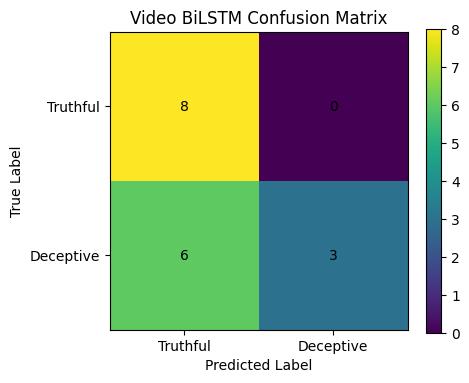

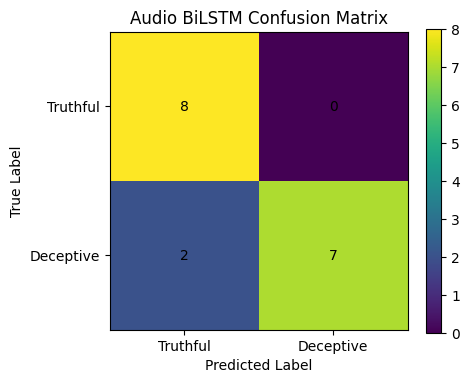

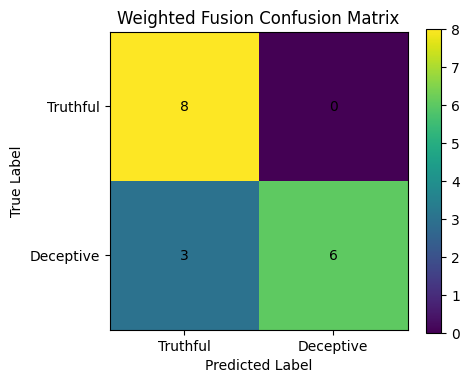

Video CM:
 [[8 0]
 [6 3]]
Audio CM:
 [[8 0]
 [2 7]]
Fusion CM:
 [[8 0]
 [3 6]]


In [23]:
# Cell 15 — Plot confusion matrices
video_cm = plot_confusion_matrix(
    y_true,
    valid_eval_df["video_pred"].values,
    "Video BiLSTM Confusion Matrix",
    OUTPUT_DIR / "video_confusion_matrix.png"
)

audio_cm = plot_confusion_matrix(
    y_true,
    valid_eval_df["audio_pred"].values,
    "Audio BiLSTM Confusion Matrix",
    OUTPUT_DIR / "audio_confusion_matrix.png"
)

fusion_cm = plot_confusion_matrix(
    y_true,
    valid_eval_df["fusion_pred"].values,
    "Weighted Fusion Confusion Matrix",
    OUTPUT_DIR / "fusion_confusion_matrix.png"
)

print("Video CM:\n", video_cm)
print("Audio CM:\n", audio_cm)
print("Fusion CM:\n", fusion_cm)

In [24]:
# Cell 16 — Fusion weight comparison
weight_results = []

for video_weight in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    audio_weight = 1.0 - video_weight

    scores = (
        video_weight * valid_eval_df["video_score"].values +
        audio_weight * valid_eval_df["audio_score"].values
    )

    preds = (scores >= THRESHOLD).astype(int)

    metrics = calculate_binary_metrics(
        y_true=y_true,
        y_pred=preds,
        y_score=scores,
    )

    weight_results.append({
        "video_weight": video_weight,
        "audio_weight": audio_weight,
        "threshold": THRESHOLD,
        **metrics,
    })

weight_comparison_df = pd.DataFrame(weight_results)

display(weight_comparison_df)

weight_path = OUTPUT_DIR / "fusion_weight_comparison.csv"
weight_comparison_df.to_csv(weight_path, index=False)

print("Saved weight comparison:", weight_path)

,video_weight,audio_weight,threshold,accuracy,precision,recall,f1,roc_auc
0,0.2,0.8,0.5,0.882353,1.0,0.777778,0.875,0.972222
1,0.3,0.7,0.5,0.823529,1.0,0.666667,0.800,0.958333
2,0.4,0.6,0.5,0.823529,1.0,0.666667,0.800,0.944444
3,0.5,0.5,0.5,0.823529,1.0,0.666667,0.800,0.944444
4,0.6,0.4,0.5,0.823529,1.0,0.666667,0.800,0.944444
5,0.7,0.3,0.5,0.647059,1.0,0.333333,0.500,0.930556
6,0.8,0.2,0.5,0.647059,1.0,0.333333,0.500,0.888889


Saved weight comparison: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\fusion_weight_comparison.csv


In [25]:
# Cell 17 — Select best fusion weight
best_weight_row = weight_comparison_df.sort_values(
    by=["f1", "accuracy", "roc_auc"],
    ascending=False,
    na_position="last"
).iloc[0]

print("Best weight row:")
display(best_weight_row)

Best weight row:


video_weight    0.200000
audio_weight    0.800000
threshold       0.500000
accuracy        0.882353
precision       1.000000
recall          0.777778
f1              0.875000
roc_auc         0.972222
Name: 0, dtype: float64

In [26]:
# Cell 18 — Generate report-ready comparison table
report_ready_df = comparison_df.copy()

for column in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    report_ready_df[column] = report_ready_df[column].apply(
        lambda value: None if value is None or pd.isna(value) else round(float(value), 4)
    )

display(report_ready_df)

report_ready_path = OUTPUT_DIR / "report_ready_model_comparison.csv"
report_ready_df.to_csv(report_ready_path, index=False)

print("Saved report-ready table:", report_ready_path)

,model,accuracy,precision,recall,f1,roc_auc
0,Video BiLSTM,0.6471,1.0,0.3333,0.500,0.5139
1,Audio BiLSTM,0.8824,1.0,0.7778,0.875,0.9722
2,Weighted Fusion (0.6/0.4),0.8235,1.0,0.6667,0.800,0.9306


Saved report-ready table: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\report_ready_model_comparison.csv


In [27]:
# Cell 19 — Save full evaluation summary JSON
evaluation_summary = {
    "evaluation_type": "shared_video_level_multimodal_evaluation",
    "description": (
        "The final deployed video, audio, and fusion inference pipelines were "
        "evaluated on a shared video-level test split. The video and audio "
        "models were not retrained. Weighted late fusion was applied using "
        "video/audio model output scores."
    ),
    "label_mapping": {
        "truthful": 0,
        "deceptive": 1,
    },
    "split": {
        "train_videos": int(len(train_df)),
        "validation_videos": int(len(val_df)),
        "test_videos": int(len(test_df)),
        "successful_test_predictions": int(len(predictions_df)),
        "failed_test_predictions": int(len(failed_df)),
        "valid_evaluation_videos": int(len(valid_eval_df)),
    },
    "default_fusion": {
        "video_weight": VIDEO_WEIGHT,
        "audio_weight": AUDIO_WEIGHT,
        "threshold": THRESHOLD,
        "metrics": fusion_metrics,
    },
    "video_metrics": video_metrics,
    "audio_metrics": audio_metrics,
    "fusion_metrics": fusion_metrics,
    "best_weight_by_f1": {
        "video_weight": float(best_weight_row["video_weight"]),
        "audio_weight": float(best_weight_row["audio_weight"]),
        "threshold": float(best_weight_row["threshold"]),
        "accuracy": float(best_weight_row["accuracy"]),
        "precision": float(best_weight_row["precision"]),
        "recall": float(best_weight_row["recall"]),
        "f1": float(best_weight_row["f1"]),
        "roc_auc": None
        if pd.isna(best_weight_row["roc_auc"])
        else float(best_weight_row["roc_auc"]),
    },
    "outputs": {
        "shared_train_videos": "shared_train_videos.csv",
        "shared_val_videos": "shared_val_videos.csv",
        "shared_test_videos": "shared_test_videos.csv",
        "shared_test_predictions": "shared_test_predictions.csv",
        "failed_videos": "shared_test_failed_videos.csv",
        "model_comparison_metrics": "model_comparison_metrics.csv",
        "report_ready_model_comparison": "report_ready_model_comparison.csv",
        "fusion_weight_comparison": "fusion_weight_comparison.csv",
        "video_confusion_matrix": "video_confusion_matrix.png",
        "audio_confusion_matrix": "audio_confusion_matrix.png",
        "fusion_confusion_matrix": "fusion_confusion_matrix.png",
    },
}

summary_path = OUTPUT_DIR / "fusion_evaluation_summary.json"

with open(summary_path, "w") as file:
    json.dump(evaluation_summary, file, indent=4)

print("Saved evaluation summary:", summary_path)
evaluation_summary

Saved evaluation summary: d:\NSBM\3rd Year\Final Year Project\Product Development\Github\Mutimodal-Deception-Dectection\Demos\Real Life Trial Data (Demo 5)\train\fusion_evaluation_outputs\fusion_evaluation_summary.json


{'evaluation_type': 'shared_video_level_multimodal_evaluation',
 'description': 'The final deployed video, audio, and fusion inference pipelines were evaluated on a shared video-level test split. The video and audio models were not retrained. Weighted late fusion was applied using video/audio model output scores.',
 'label_mapping': {'truthful': 0, 'deceptive': 1},
 'split': {'train_videos': 84,
  'validation_videos': 18,
  'test_videos': 19,
  'successful_test_predictions': 17,
  'failed_test_predictions': 2,
  'valid_evaluation_videos': 17},
 'default_fusion': {'video_weight': 0.6,
  'audio_weight': 0.4,
  'threshold': 0.5,
  'metrics': {'accuracy': 0.8235294117647058,
   'precision': 1.0,
   'recall': 0.6666666666666666,
   'f1': 0.8,
   'roc_auc': 0.9305555555555556}},
 'video_metrics': {'accuracy': 0.6470588235294118,
  'precision': 1.0,
  'recall': 0.3333333333333333,
  'f1': 0.5,
  'roc_auc': 0.5138888888888888},
 'audio_metrics': {'accuracy': 0.8823529411764706,
  'precision': 

In [28]:
# Cell 20 — Final report interpretation text
print(
    f"""
Fusion Evaluation Summary

A shared video-level test split was created from the Real-life Trial Deception
Detection dataset. The final deployed Video BiLSTM, Audio BiLSTM, and weighted
late-fusion pipelines were evaluated on the same test videos.

The models were not retrained in this notebook. Instead, the notebook used the
existing product inference pipeline:
- predict_video_timeline()
- predict_audio_timeline()
- fuse_video_audio_timelines()

Default fusion configuration:
- Video weight: {VIDEO_WEIGHT}
- Audio weight: {AUDIO_WEIGHT}
- Decision threshold: {THRESHOLD}

Evaluation videos:
- Test videos: {len(test_df)}
- Successful predictions: {len(predictions_df)}
- Valid evaluation videos: {len(valid_eval_df)}
- Failed videos: {len(failed_df)}

Video BiLSTM:
- Accuracy: {video_metrics["accuracy"]:.4f}
- Precision: {video_metrics["precision"]:.4f}
- Recall: {video_metrics["recall"]:.4f}
- F1-score: {video_metrics["f1"]:.4f}
- ROC-AUC: {video_metrics["roc_auc"]}

Audio BiLSTM:
- Accuracy: {audio_metrics["accuracy"]:.4f}
- Precision: {audio_metrics["precision"]:.4f}
- Recall: {audio_metrics["recall"]:.4f}
- F1-score: {audio_metrics["f1"]:.4f}
- ROC-AUC: {audio_metrics["roc_auc"]}

Weighted Fusion:
- Accuracy: {fusion_metrics["accuracy"]:.4f}
- Precision: {fusion_metrics["precision"]:.4f}
- Recall: {fusion_metrics["recall"]:.4f}
- F1-score: {fusion_metrics["f1"]:.4f}
- ROC-AUC: {fusion_metrics["roc_auc"]}

Best tested weight by F1-score:
- Video weight: {best_weight_row["video_weight"]}
- Audio weight: {best_weight_row["audio_weight"]}
- F1-score: {best_weight_row["f1"]:.4f}
"""
)


Fusion Evaluation Summary

A shared video-level test split was created from the Real-life Trial Deception
Detection dataset. The final deployed Video BiLSTM, Audio BiLSTM, and weighted
late-fusion pipelines were evaluated on the same test videos.

The models were not retrained in this notebook. Instead, the notebook used the
existing product inference pipeline:
- predict_video_timeline()
- predict_audio_timeline()
- fuse_video_audio_timelines()

Default fusion configuration:
- Video weight: 0.6
- Audio weight: 0.4
- Decision threshold: 0.5

Evaluation videos:
- Test videos: 19
- Successful predictions: 17
- Valid evaluation videos: 17
- Failed videos: 2

Video BiLSTM:
- Accuracy: 0.6471
- Precision: 1.0000
- Recall: 0.3333
- F1-score: 0.5000
- ROC-AUC: 0.5138888888888888

Audio BiLSTM:
- Accuracy: 0.8824
- Precision: 1.0000
- Recall: 0.7778
- F1-score: 0.8750
- ROC-AUC: 0.9722222222222222

Weighted Fusion:
- Accuracy: 0.8235
- Precision: 1.0000
- Recall: 0.6667
- F1-score: 0.8000
- RO